# Analyzing Tweets Sentiment on the Pfizer Vaccine with Python
Twitter hosts millions of short, real-time opinions, making it a rich source for understanding how people feel about important topics. In this project, we explore sentiment toward the Pfizer COVID-19 vaccine using a collection of tweets to see overall attitudes and themes.

<div align="center">
<img src="https://c.files.bbci.co.uk/1229D/production/_118379347_f959b3bf-db0b-4dc9-822e-64a7ea6170e0.jpg" />
</div>

## Project Overview
We'll work with a tweet dataset originally shared on Kaggle and compiled from Twitter during the period of widespread discussion about the Pfizer vaccine. To follow along, you can load the CSV directly from this link: [vaccination_tweets.csv](https://raw.githubusercontent.com/amankharwal/Website-data/master/vaccination_tweets.csv).

## 1. Importing Libraries
First, let's import the necessary libraries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import neattext as ntx
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from wordcloud import WordCloud
from PIL import Image

import warnings

### Configuration
Let's configure the necessary settings.
- Ignore warnings for cleaner output.
- Set default figure size to 12x8 inches for plots.

In [2]:
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 8)

## 2. Data Loading
Next, we will read the dataset from the URL and take a quick look at its structure.

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/amankharwal/Website-data/master/vaccination_tweets.csv')

In [4]:
df.head()

,id,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,text,hashtags,source,retweets,favorites,is_retweet
0,1340539111971516416,Rachel Roh,"La Crescenta-Montrose, CA",Aggregator of Asian American news; scanning di...,2009-04-08 17:52:46,405,1692,3247,False,2020-12-20 06:06:44,Same folks said daikon paste could treat a cyt...,['PfizerBioNTech'],Twitter for Android,0,0,False
1,1338158543359250433,Albert Fong,"San Francisco, CA","Marketing dude, tech geek, heavy metal & '80s ...",2009-09-21 15:27:30,834,666,178,False,2020-12-13 16:27:13,While the world has been on the wrong side of ...,NaN,Twitter Web App,1,1,False
2,1337858199140118533,eli🇱🇹🇪🇺👌,Your Bed,"heil, hydra 🖐☺",2020-06-25 23:30:28,10,88,155,False,2020-12-12 20:33:45,#coronavirus #SputnikV #AstraZeneca #PfizerBio...,"['coronavirus', 'SputnikV', 'AstraZeneca', 'Pf...",Twitter for Android,0,0,False
3,1337855739918835717,Charles Adler,"Vancouver, BC - Canada","Hosting ""CharlesAdlerTonight"" Global News Radi...",2008-09-10 11:28:53,49165,3933,21853,True,2020-12-12 20:23:59,"Facts are immutable, Senator, even when you're...",NaN,Twitter Web App,446,2129,False
4,1337854064604966912,Citizen News Channel,NaN,Citizen News Channel bringing you an alternati...,2020-04-23 17:58:42,152,580,1473,False,2020-12-12 20:17:19,Explain to me again why we need a vaccine @Bor...,"['whereareallthesickpeople', 'PfizerBioNTech']",Twitter for iPhone,0,0,False


In [5]:
df.shape

(8082, 16)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8082 entries, 0 to 8081
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   id                8082 non-null   int64 
 1   user_name         8082 non-null   object
 2   user_location     6452 non-null   object
 3   user_description  7575 non-null   object
 4   user_created      8082 non-null   object
 5   user_followers    8082 non-null   int64 
 6   user_friends      8082 non-null   int64 
 7   user_favourites   8082 non-null   int64 
 8   user_verified     8082 non-null   bool  
 9   date              8082 non-null   object
 10  text              8082 non-null   object
 11  hashtags          6133 non-null   object
 12  source            8081 non-null   object
 13  retweets          8082 non-null   int64 
 14  favorites         8082 non-null   int64 
 15  is_retweet        8082 non-null   bool  
dtypes: bool(2), int64(6), object(8)
memory usage: 899.9+ KB


In [7]:
df.isnull().sum()

id                     0
user_name              0
user_location       1630
user_description     507
user_created           0
user_followers         0
user_friends           0
user_favourites        0
user_verified          0
date                   0
text                   0
hashtags            1949
source                 1
retweets               0
favorites              0
is_retweet             0
dtype: int64

These null values won't affect the task of sentiment analysis, to keep things simple, let's drop the columns that has null values.

In [8]:
df.drop(columns=['user_location', 'user_description', 'hashtags', 'source'], inplace=True)

## 3. Data Preprocessing
Let's clean the text data to make it ready for the sentiment analysis.

In [9]:
stemmer = nltk.SnowballStemmer('english')

In [10]:
# Function to clean the text
def clean_text(text):
    text = text.lower()
    text = ntx.remove_emojis(text)
    text = ntx.remove_emails(text)
    text = ntx.remove_phone_numbers(text)
    text = ntx.remove_urls(text)
    text = ntx.remove_hashtags(text)
    text = ntx.remove_special_characters(text)
    text = ntx.remove_multiple_spaces(text)
    text = ntx.remove_dates(text)
    text = text.strip()
    text = ntx.remove_stopwords(text)
    text = ntx.normalize(text)
    text = [stemmer.stem(word) for word in text.split()]
    text = " ".join(text)
    return text

df['text'].apply(clean_text)[:10]

0            folk said daikon past treat cytokin storm
1    world wrong histori year hope biggest vaccin e...
2                            russian vaccin creat year
3    fact immut senat your ethic sturdi acknowledg ...
4         explain need vaccin borisjohnson matthancock
5    use adviceguid covid vaccin safe whilst breast...
6    bit sad claim fame success patriot competit us...
7                                  bright day best win
8                                     covid vaccin get
9                           state start get monday say
Name: text, dtype: object

In [11]:
df['text_clean'] = df['text'].apply(clean_text)

In [12]:
df[['text', 'text_clean']].head()

,text,text_clean
0,Same folks said daikon paste could treat a cyt...,folk said daikon past treat cytokin storm
1,While the world has been on the wrong side of ...,world wrong histori year hope biggest vaccin e...
2,#coronavirus #SputnikV #AstraZeneca #PfizerBio...,russian vaccin creat year
3,"Facts are immutable, Senator, even when you're...",fact immut senat your ethic sturdi acknowledg ...
4,Explain to me again why we need a vaccine @Bor...,explain need vaccin borisjohnson matthancock


We can see that the text is cleaned and ready for the sentiment analysis.

## 4. Visualization
Let's visualize the data with WordCloud.

In [13]:
def generate_wordcloud(text):
    mask = np.array(Image.open('../assets/cloud.png'))
    wordcloud = WordCloud(width=800, height=400, background_color='white', mask=mask).generate(text)
    plt.figure(figsize=(15, 8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()

In [14]:
texts = " ".join(df.text_clean)

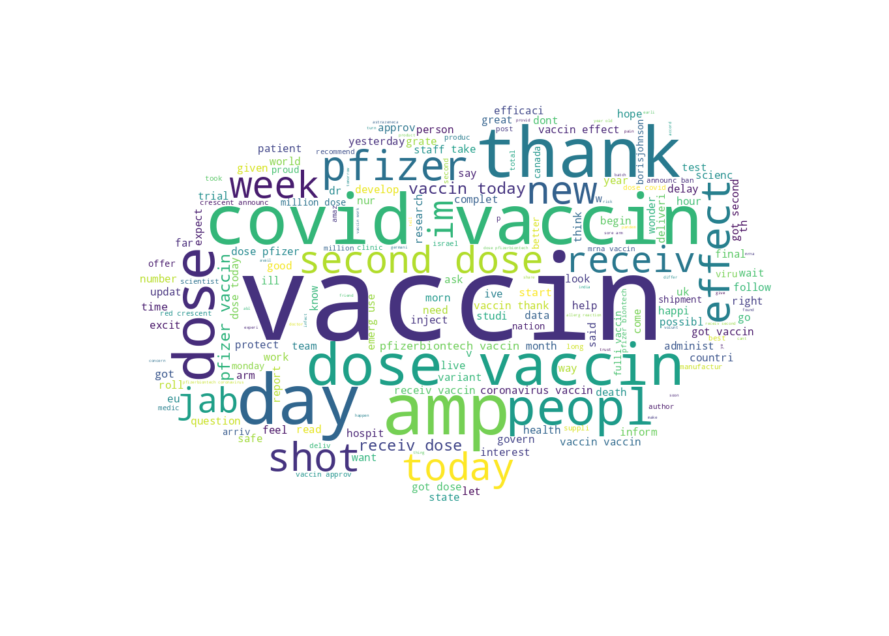

In [15]:
generate_wordcloud(texts)

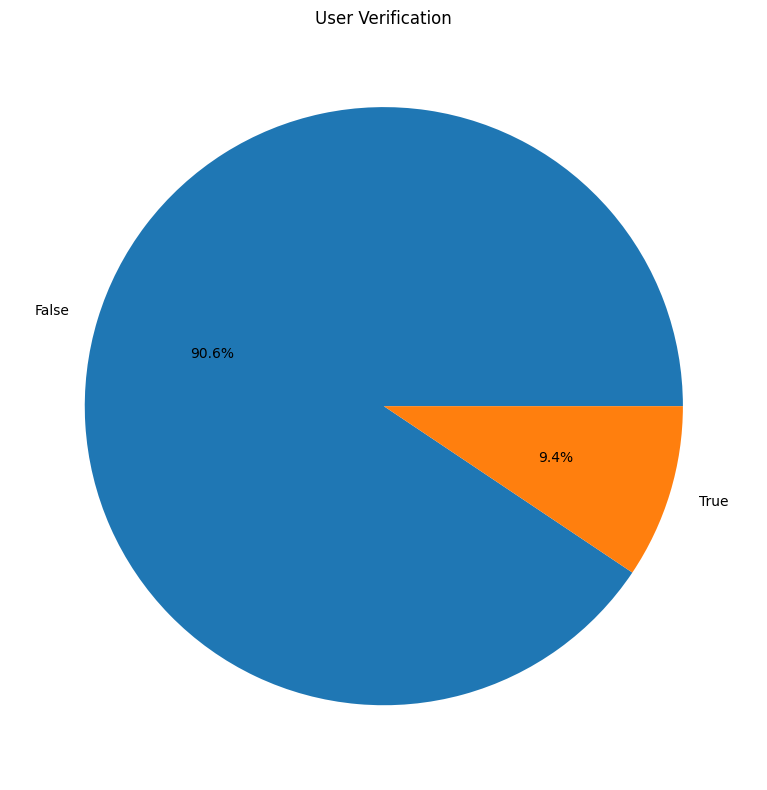

In [16]:
df['user_verified'].value_counts().plot.pie(autopct='%1.1f%%')
plt.ylabel('')
plt.title('User Verification')
plt.tight_layout()

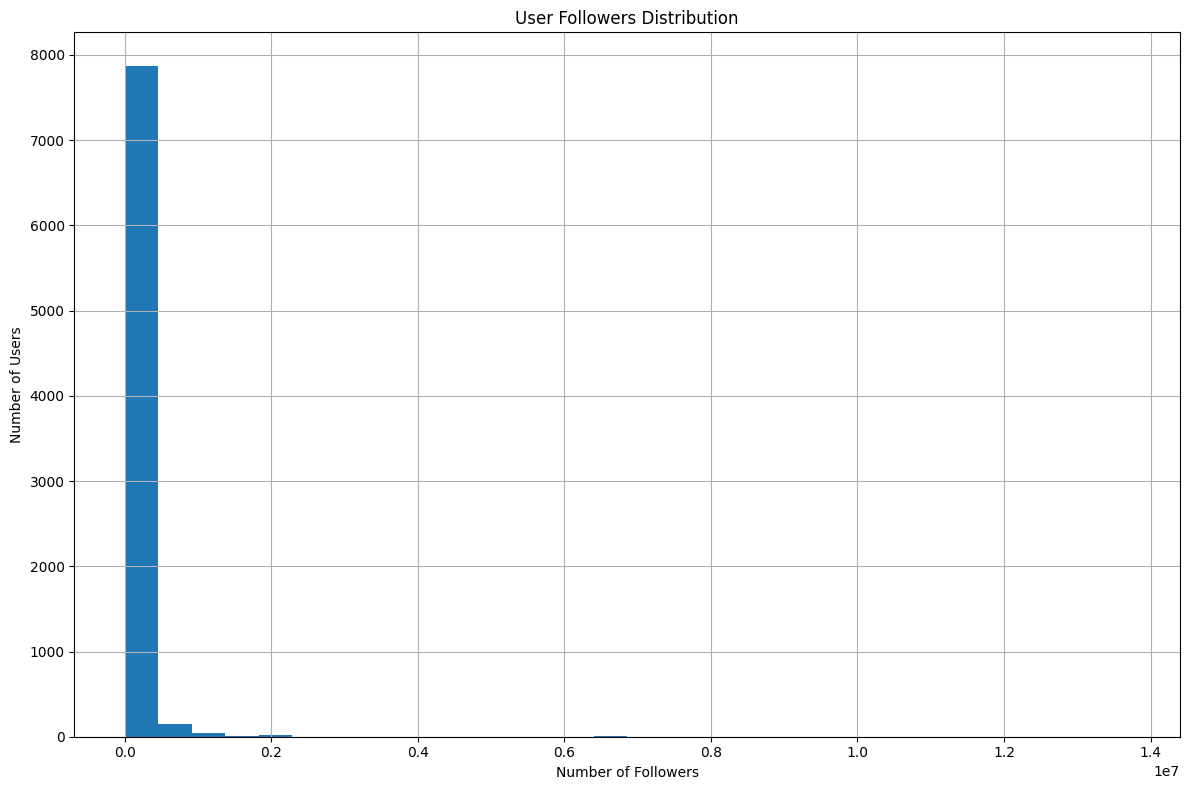

In [17]:
df['user_followers'].hist(bins=30)
plt.xlabel('Number of Followers')
plt.ylabel('Number of Users')
plt.title('User Followers Distribution')
plt.tight_layout()

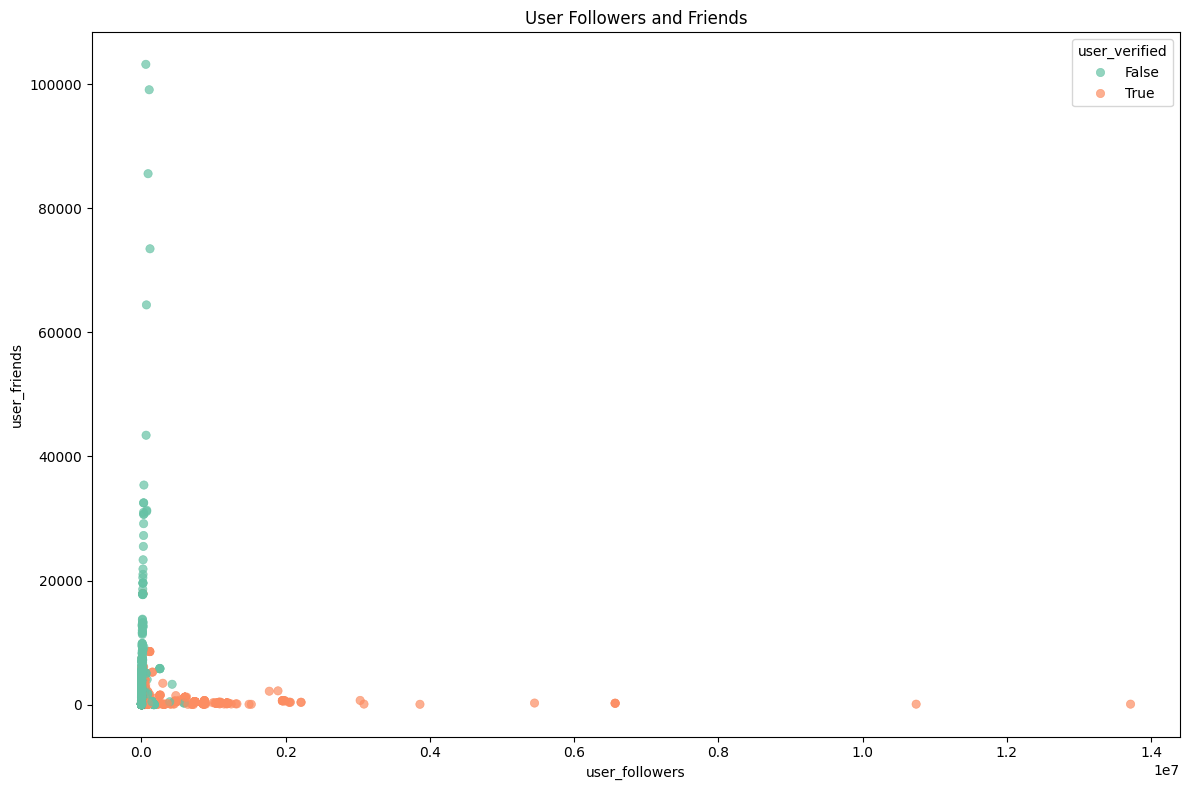

In [18]:
sns.scatterplot(
    df,
    x='user_followers',
    y='user_friends',
    hue='user_verified',
    palette='Set2',
    edgecolor=None,
    alpha=0.7
)
plt.title('User Followers and Friends')
plt.tight_layout()

## 5. Sentiment Analysis
Let's analyze the sentiment of the tweets.

In [19]:
# if not downloaded, download it
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/tuncer/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [20]:
sia = SentimentIntensityAnalyzer()

In [21]:
sia.polarity_scores(df['text_clean'][0])

{'neg': 0.0, 'neu': 0.69, 'pos': 0.31, 'compound': 0.4019}

In [22]:
df[['Positive', 'Negative', 'Neutral', 'Compound']] = df['text_clean'].apply(lambda x: pd.Series(sia.polarity_scores(x)))

In [23]:
df.head()

,id,user_name,user_created,user_followers,user_friends,user_favourites,user_verified,date,text,retweets,favorites,is_retweet,text_clean,Positive,Negative,Neutral,Compound
0,1340539111971516416,Rachel Roh,2009-04-08 17:52:46,405,1692,3247,False,2020-12-20 06:06:44,Same folks said daikon paste could treat a cyt...,0,0,False,folk said daikon past treat cytokin storm,0.000,0.690,0.310,0.4019
1,1338158543359250433,Albert Fong,2009-09-21 15:27:30,834,666,178,False,2020-12-13 16:27:13,While the world has been on the wrong side of ...,1,1,False,world wrong histori year hope biggest vaccin e...,0.221,0.571,0.207,-0.0516
2,1337858199140118533,eli🇱🇹🇪🇺👌,2020-06-25 23:30:28,10,88,155,False,2020-12-12 20:33:45,#coronavirus #SputnikV #AstraZeneca #PfizerBio...,0,0,False,russian vaccin creat year,0.000,1.000,0.000,0.0000
3,1337855739918835717,Charles Adler,2008-09-10 11:28:53,49165,3933,21853,True,2020-12-12 20:23:59,"Facts are immutable, Senator, even when you're...",446,2129,False,fact immut senat your ethic sturdi acknowledg ...,0.000,1.000,0.000,0.0000
4,1337854064604966912,Citizen News Channel,2020-04-23 17:58:42,152,580,1473,False,2020-12-12 20:17:19,Explain to me again why we need a vaccine @Bor...,0,0,False,explain need vaccin borisjohnson matthancock,0.000,1.000,0.000,0.0000


In [24]:
df.agg({
    'Positive': ['sum', 'mean', 'std'],
    'Negative': ['sum', 'mean', 'std'],
    'Neutral': ['sum', 'mean', 'std'],
    'Compound': ['sum', 'mean', 'std']
}).T

,sum,mean,std
Positive,469.5940,0.058104,0.138173
Negative,6597.9290,0.816373,0.231664
Neutral,954.4690,0.118098,0.191069
Compound,562.6099,0.069613,0.312134


The total positive and neutral very less than the negative. So, we can say that the discussion in the X(Twitter) is mostly negative for the Pfizer vaccine.

## 6. Conclusion
This project analyzed sentiment toward the Pfizer COVID-19 vaccine using 8,082 Twitter tweets. We implemented a complete NLP pipeline including data preprocessing, text cleaning, visualization, and sentiment analysis using VADER.

### Key Insights
- **Overall Sentiment**: The analysis revealed predominantly negative sentiment toward the Pfizer vaccine on Twitter
- **Data Quality**: Successfully processed 8,082 tweets with comprehensive text cleaning and normalization
- **User Demographics**: Analyzed both verified and unverified users with diverse follower counts
- **Visualization**: Word clouds and charts revealed key discussion themes and user characteristics

### Technical Achievements
- Implemented robust text preprocessing using `neattext` library
- Applied VADER sentiment analysis for social media text
- Created informative visualizations including word clouds and user demographics
- Generated quantitative sentiment scores (Positive, Negative, Neutral, Compound)

### Future Improvements
- **Enhanced Analysis**: Multi-class sentiment, aspect-based analysis, emotion detection
- **Advanced NLP**: Topic modeling, named entity recognition, temporal analysis
- **Better Models**: Use transformer models (BERT, RoBERTa) for better context understanding
- **Data Expansion**: Larger datasets, cross-platform analysis, real-time monitoring
- **Applications**: Public health communication, misinformation detection, predictive modeling

### Summary
This project successfully demonstrated sentiment analysis capabilities for health-related social media content. While revealing negative sentiment toward the Pfizer vaccine, results should be interpreted within social media context. The work provides a foundation for understanding public discourse on vaccines and offers valuable insights for public health communication strategies.